# F1 ERS Deployment Strategy Simulator

**Research question:** Is the timing of ERS deployment more important than total energy deployed when maximizing lap time benefit under FIA constraints?

**Key finding:** An offline-optimized strategy extracts **0.40 s** from 4 MJ at Monza; an indiscriminate strategy extracts **0.14 s** from the same budget — a **2.8× improvement from timing alone**.

---

**Notebook structure:**
1. Setup & experiment run
2. Exploratory telemetry (single lap, Monza)
3. Strategy comparison — all strategies, all SOC levels
4. Research figures A–E (publication quality)


## Section 1 — Setup & Data Generation

In [1]:
import os

os.chdir("/workspaces/F1")

print("Working directory:", os.getcwd())

os.makedirs("results", exist_ok=True)

Working directory: /workspaces/F1


In [2]:
!pip install -r requirements.txt

In [3]:
!ls results

fig_a_improvement_by_track.png	 telemetry_baseline_soc4.csv
fig_b_energy_vs_improvement.png  telemetry_baseline_soc6.csv
fig_c_tornado.png		 telemetry_baseline_soc8.csv
fig_d_pareto.png		 telemetry_conservative_soc4.csv
fig_e_stint.png			 telemetry_conservative_soc6.csv
monza_telemetry.csv		 telemetry_conservative_soc8.csv
sensitivity_2d.csv		 telemetry_lookahead_soc4.csv
sensitivity_oat.csv		 telemetry_lookahead_soc6.csv
stint_results.csv		 telemetry_lookahead_soc8.csv
strategy_results.csv		 telemetry_optimal_soc4.csv
telemetry_aggressive_soc4.csv	 telemetry_optimal_soc6.csv
telemetry_aggressive_soc6.csv	 telemetry_optimal_soc8.csv
telemetry_aggressive_soc8.csv


In [4]:
# Generate strategy results (creates results/strategy_results.csv and telemetry files)
!python -m experiments.run_experiment


=== MONZA ===
  baseline      SOC=0.4  lap=81.718s  +0.0000s  deployed=0.00MJ  soc_end=1.000
  conservative  SOC=0.4  lap=81.718s  +0.0000s  deployed=2.83MJ  soc_end=0.596
  aggressive    SOC=0.4  lap=81.574s  +0.1440s  deployed=4.00MJ  soc_end=0.363
  lookahead     SOC=0.4  lap=81.635s  +0.0833s  deployed=4.00MJ  soc_end=0.363
  optimal       SOC=0.4  lap=81.318s  +0.4000s  deployed=4.00MJ  soc_end=0.363
  baseline      SOC=0.6  lap=81.718s  +0.0000s  deployed=0.00MJ  soc_end=1.000
  conservative  SOC=0.6  lap=81.718s  +0.0000s  deployed=3.83MJ  soc_end=0.597
  aggressive    SOC=0.6  lap=81.574s  +0.1440s  deployed=4.00MJ  soc_end=0.563
  lookahead     SOC=0.6  lap=81.635s  +0.0833s  deployed=4.00MJ  soc_end=0.408
  optimal       SOC=0.6  lap=81.318s  +0.4000s  deployed=4.00MJ  soc_end=0.485
  baseline      SOC=0.8  lap=81.718s  +0.0000s  deployed=0.00MJ  soc_end=1.000
  conservative  SOC=0.8  lap=81.617s  +0.1008s  deployed=4.00MJ  soc_end=0.763
  aggressive    SOC=0.8  lap=81.574s 

In [5]:
# Load strategy results
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("results/strategy_results.csv")
strategies = ["conservative", "aggressive", "lookahead"]
socs = [0.4, 0.6, 0.8]
colors = {"conservative": "blue", "aggressive": "red", "lookahead": "green"}

## Section 2 — Exploratory Telemetry (Single Lap, Monza)

Raw telemetry from a single Monza lap. Used to verify the simulation is behaving physically — SOC in bounds, power within limits, speed profile realistic.

In [6]:
import pandas as pd

df = pd.read_csv("results/monza_telemetry.csv")

df.head()

,time,power,soc,distance,speed
0,0.0,0.0,0.6,7.5,55.879630
1,0.2,0.0,0.6,22.5,56.527778
2,0.4,0.0,0.6,37.5,57.175926
3,0.6,0.0,0.6,52.5,57.824074
4,0.8,0.0,0.6,67.5,58.472222


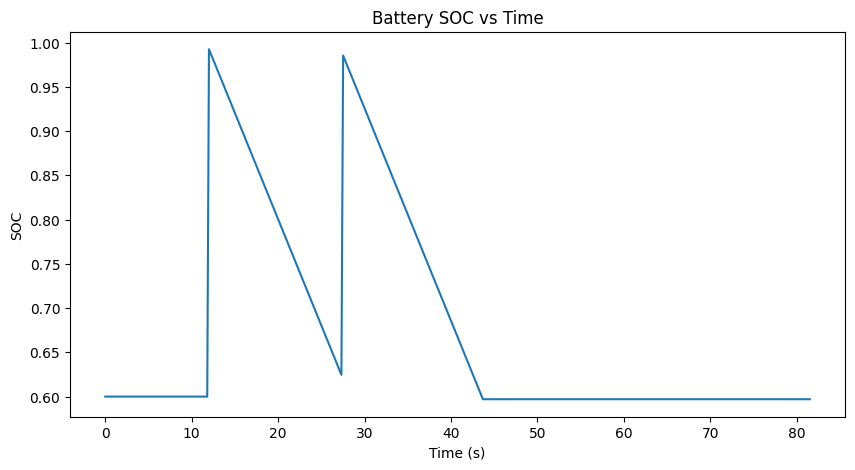

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["soc"])
plt.xlabel("Time (s)")
plt.ylabel("SOC")
plt.title("Battery SOC vs Time")
plt.show()


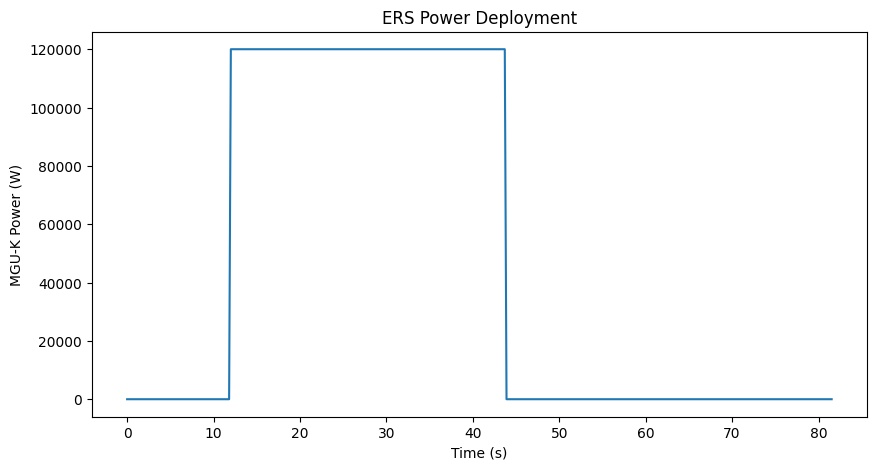

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["power"])
plt.xlabel("Time (s)")
plt.ylabel("MGU-K Power (W)")
plt.title("ERS Power Deployment")
plt.show()

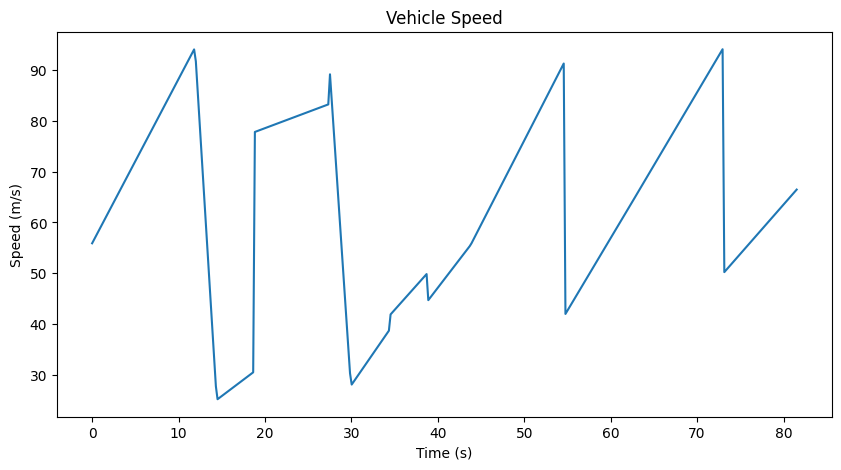

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["speed"])
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("Vehicle Speed")
plt.show()

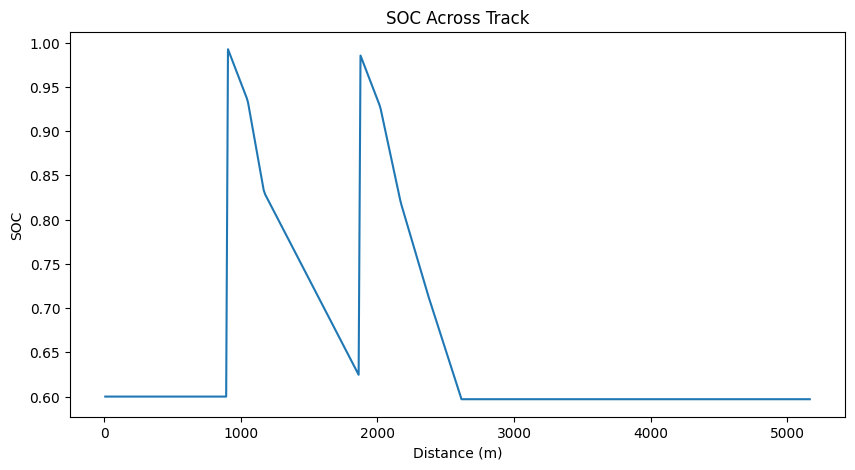

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df["distance"], df["soc"])
plt.xlabel("Distance (m)")
plt.ylabel("SOC")
plt.title("SOC Across Track")
plt.show()

In [11]:
print("Telemetry summary")

print("Min SOC:", df["soc"].min())
print("Max SOC:", df["soc"].max())

print("Max power deployed:", df["power"].max())
print("Average power:", df["power"].mean())

Telemetry summary
Min SOC: 0.5970161969332435
Max SOC: 0.9925159262572052
Max power deployed: 120000.0
Average power: 47070.217917675545


## Section 3 — Strategy Comparison (Exploratory)

All strategies across initial SOC values. These plots show the full dataset; the focused research figures are in Section 4.

AttributeError: 'DataFrame' object has no attribute 'lap_time'

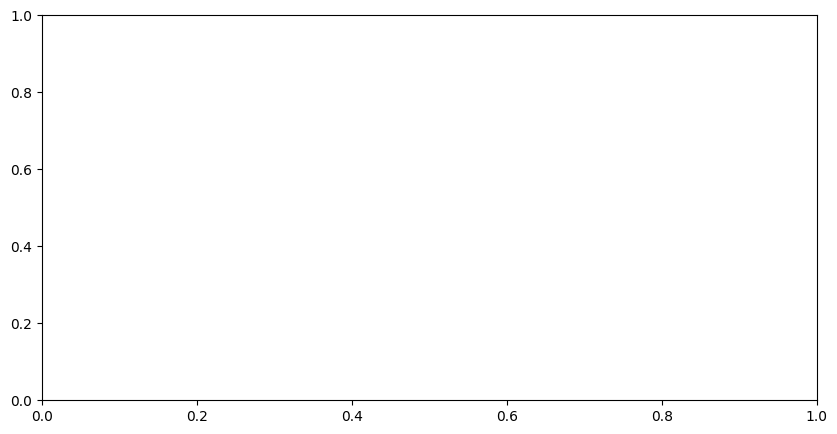

In [12]:
# 1. Lap time comparison
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.lap_time, marker="o", label=s, color=colors[s])
ax.set_xlabel("Initial SOC"); ax.set_ylabel("Lap Time (s)")
ax.set_title("Lap Time vs Initial SOC by Strategy")
ax.legend(); plt.show()

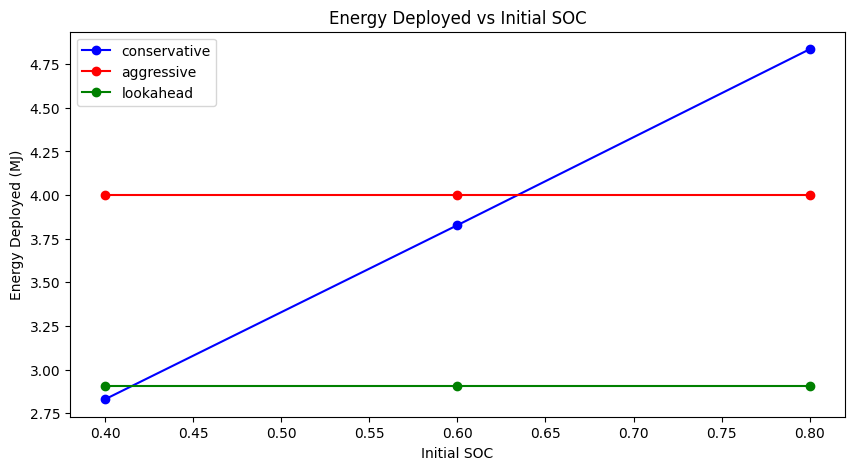

In [ ]:
# 2. Energy deployed comparison
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.energy_deployed_j / 1e6, marker="o", label=s, color=colors[s])
ax.set_xlabel("Initial SOC"); ax.set_ylabel("Energy Deployed (MJ)")
ax.set_title("Energy Deployed vs Initial SOC"); ax.legend(); plt.show()

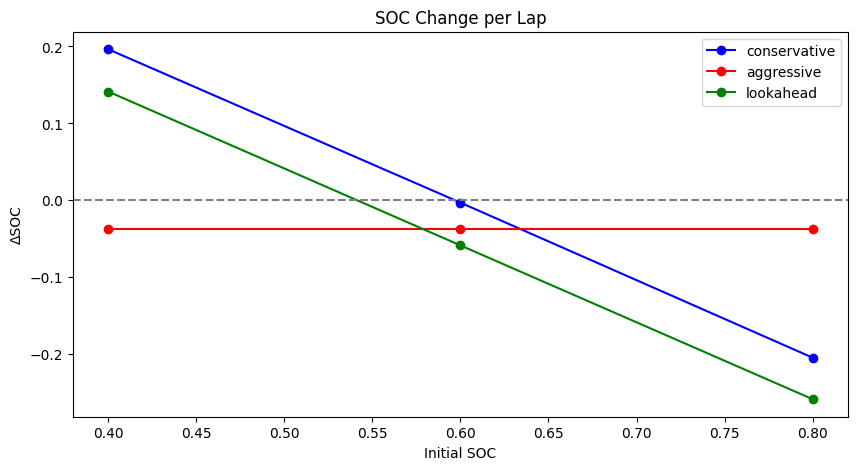

In [ ]:
# 3. SOC delta (end - start)
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.soc_end - d.initial_soc, marker="o", label=s, color=colors[s])
ax.axhline(0, linestyle="--", color="gray")
ax.set_xlabel("Initial SOC"); ax.set_ylabel("ΔSOC")
ax.set_title("SOC Change per Lap"); ax.legend(); plt.show()

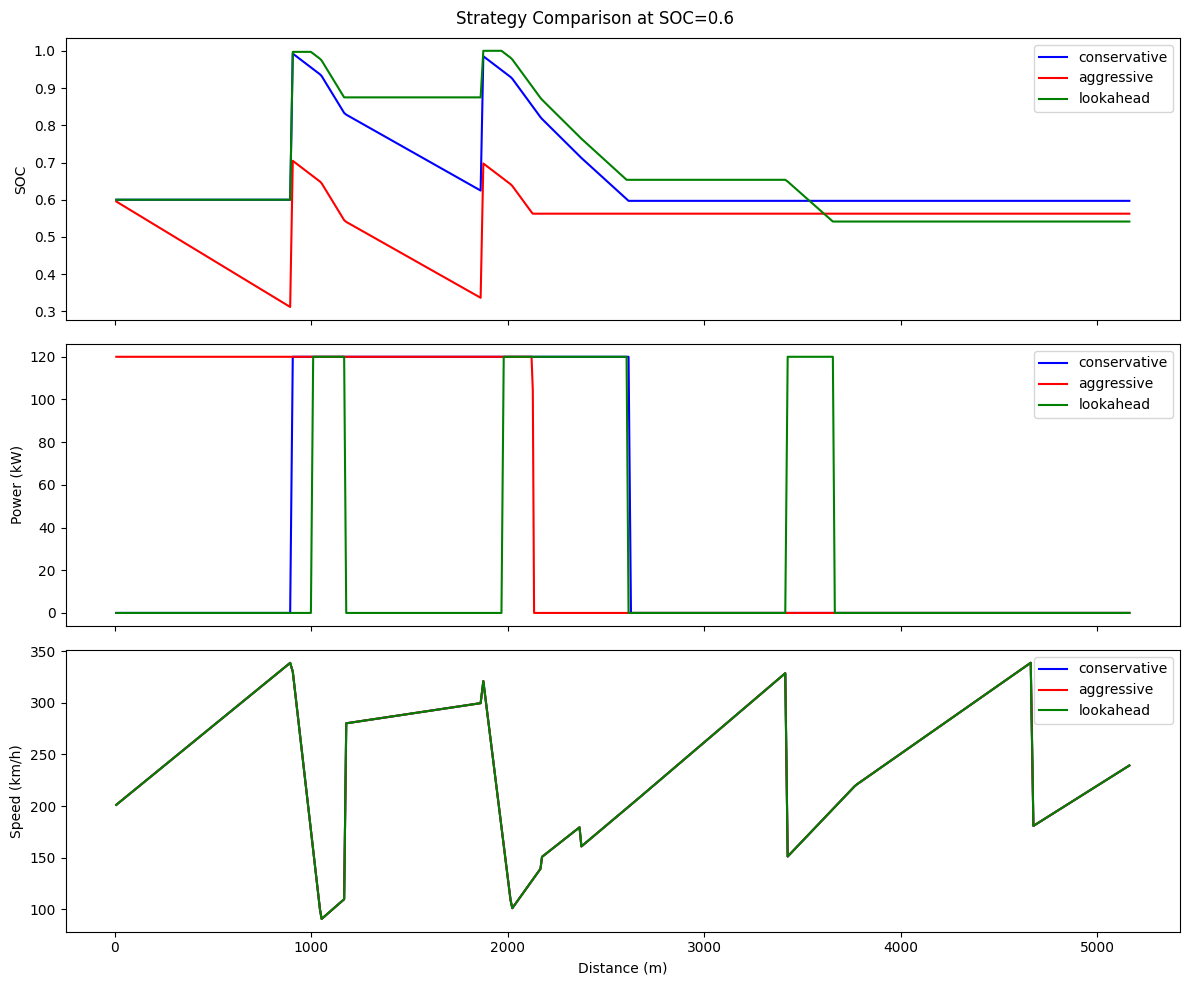

In [ ]:
# 4. Per-strategy telemetry overlay (SOC=0.6)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    axes[0].plot(tel.distance, tel.soc, label=s, color=colors[s])
    axes[1].plot(tel.distance, tel.power / 1000, label=s, color=colors[s])
    axes[2].plot(tel.distance, tel.speed * 3.6, label=s, color=colors[s])
for ax, ylabel in zip(axes, ["SOC", "Power (kW)", "Speed (km/h)"]):
    ax.set_ylabel(ylabel); ax.legend()
axes[2].set_xlabel("Distance (m)")
fig.suptitle("Strategy Comparison at SOC=0.6"); plt.tight_layout(); plt.show()

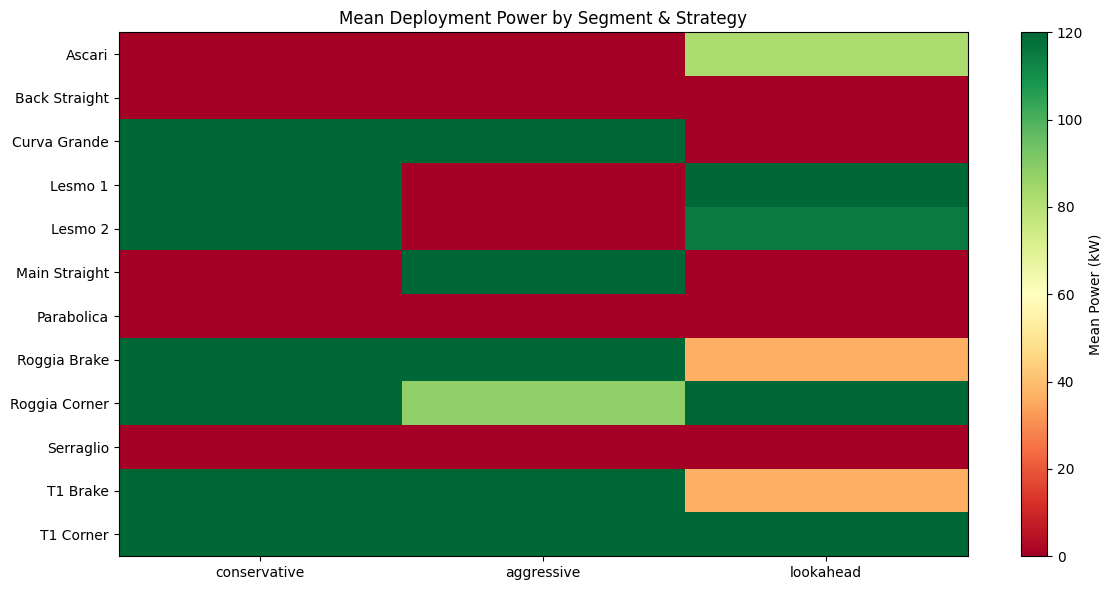

In [ ]:
# 5. Segment-level mean power heatmap
import numpy as np
seg_data = {}
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    seg_data[s] = tel.groupby("segment_name")["power"].mean() / 1000

seg_df = pd.DataFrame(seg_data)
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(seg_df.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(len(strategies))); ax.set_xticklabels(strategies)
ax.set_yticks(range(len(seg_df))); ax.set_yticklabels(seg_df.index)
plt.colorbar(im, ax=ax, label="Mean Power (kW)")
ax.set_title("Mean Deployment Power by Segment & Strategy"); plt.tight_layout(); plt.show()

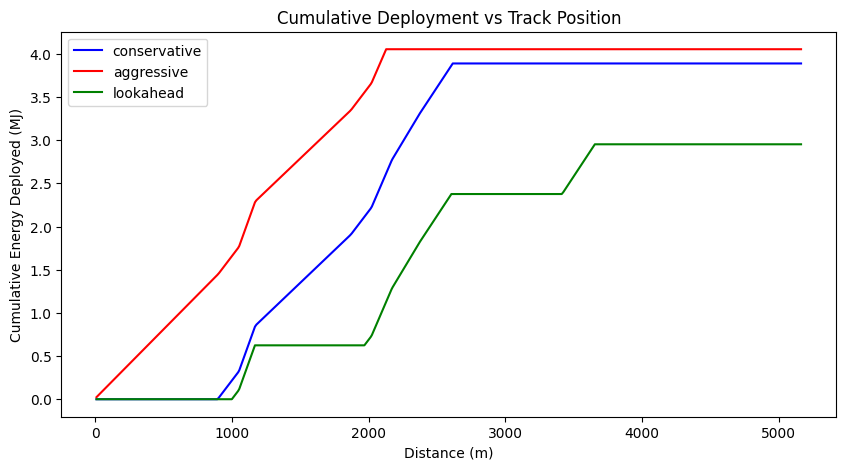

In [ ]:
# 6. Cumulative energy deployed
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    ax.plot(tel.distance, tel.cumulative_energy_deployed_j / 1e6, label=s, color=colors[s])
ax.set_xlabel("Distance (m)"); ax.set_ylabel("Cumulative Energy Deployed (MJ)")
ax.set_title("Cumulative Deployment vs Track Position"); ax.legend(); plt.show()

## Section 4 — Research Figures

These five figures form the core of the research paper (`docs/report.md`). Each addresses a specific aspect of the central research question.

| Figure | Claim tested |
|--------|-------------|
| A | Optimal always beats Aggressive; track architecture moderates the gap |
| B | Both strategies deploy 4 MJ but achieve different improvements (timing effect) |
| C | Regen efficiency is the most influential model parameter |
| D | Optimal dominates the Pareto frontier (best improvement AND best SOC preservation) |
| E | Aggressive is stint-consistent; Conservative degrades lap-over-lap |


In [ ]:

# Re-run experiment to get fresh multi-track data (safe to skip if results/ already populated)
import subprocess
subprocess.run(["python", "-m", "experiments.run_experiment"], check=True)



=== MONZA ===
  conservative  SOC=0.4  lap=81.718s  +0.0000s  deployed=2.83MJ  soc_end=0.596
  aggressive    SOC=0.4  lap=81.574s  +0.1440s  deployed=4.00MJ  soc_end=0.363
  lookahead     SOC=0.4  lap=81.608s  +0.1097s  deployed=4.49MJ  soc_end=0.265
  optimal       SOC=0.4  lap=81.305s  +0.4133s  deployed=5.31MJ  soc_end=0.100
  conservative  SOC=0.6  lap=81.718s  +0.0000s  deployed=3.83MJ  soc_end=0.597
  aggressive    SOC=0.6  lap=81.574s  +0.1440s  deployed=4.00MJ  soc_end=0.563
  lookahead     SOC=0.6  lap=81.608s  +0.1097s  deployed=4.49MJ  soc_end=0.310
  optimal       SOC=0.6  lap=81.305s  +0.4133s  deployed=6.31MJ  soc_end=0.100
  conservative  SOC=0.8  lap=81.617s  +0.1008s  deployed=4.84MJ  soc_end=0.595
  aggressive    SOC=0.8  lap=81.574s  +0.1440s  deployed=4.00MJ  soc_end=0.763
  lookahead     SOC=0.8  lap=81.608s  +0.1097s  deployed=4.49MJ  soc_end=0.310
  optimal       SOC=0.8  lap=81.305s  +0.4133s  deployed=6.87MJ  soc_end=0.100

=== SPA ===
  conservative  SOC=0.4 

CompletedProcess(args=['python', '-m', 'experiments.run_experiment'], returncode=0)

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df = pd.read_csv("results/strategy_results.csv")

STRATEGY_ORDER = ["conservative", "aggressive", "lookahead", "optimal"]
STRATEGY_COLORS = {
    "conservative": "#2196F3",   # blue
    "aggressive":   "#F44336",   # red
    "lookahead":    "#4CAF50",   # green
    "optimal":      "#FF9800",   # orange
}
TRACKS = ["monza", "spa", "monaco"]

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


### Figure A — Lap Time Improvement by Strategy and Track (SOC = 0.6)

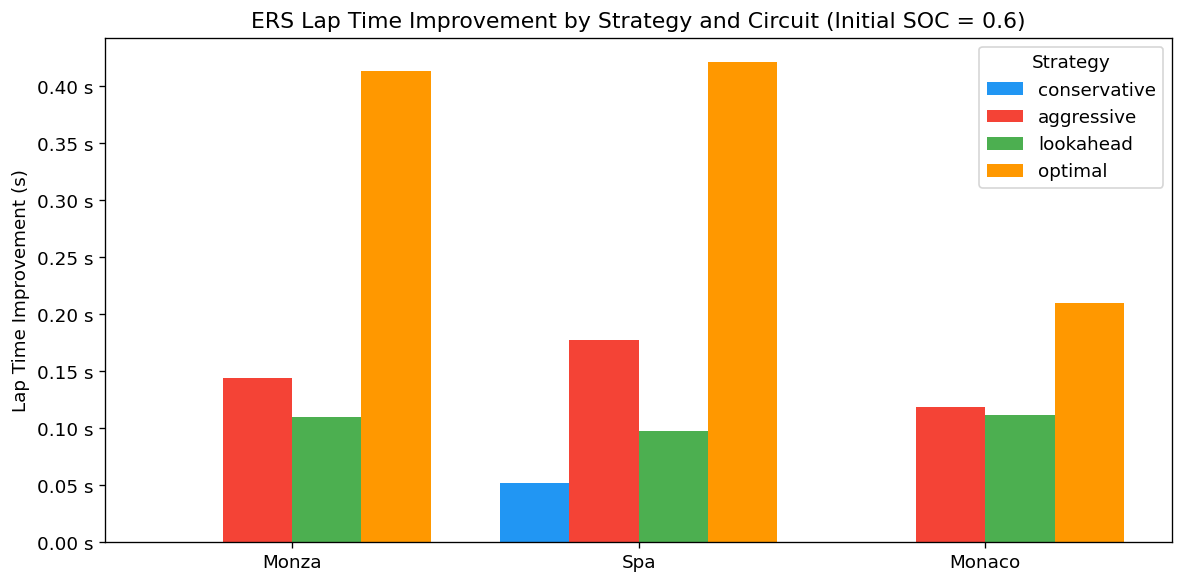

Key finding: Optimal consistently leads; Conservative earns 0s at Monza/Monaco (deploys only in corners).


In [ ]:

sub = df[df["initial_soc"] == 0.6]

x = np.arange(len(TRACKS))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 5))

for i, strat in enumerate(STRATEGY_ORDER):
    vals = [sub[(sub.track == t) & (sub.strategy == strat)]["lap_time_improvement_s"].values[0]
            for t in TRACKS]
    ax.bar(x + i * width, vals, width, label=strat, color=STRATEGY_COLORS[strat])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([t.capitalize() for t in TRACKS])
ax.set_ylabel("Lap Time Improvement (s)")
ax.set_title("ERS Lap Time Improvement by Strategy and Circuit (Initial SOC = 0.6)")
ax.legend(title="Strategy")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f s"))
plt.tight_layout()
plt.savefig("results/fig_a_improvement_by_track.png", bbox_inches="tight")
plt.show()
print("Key finding: Optimal consistently leads; Conservative earns 0s at Monza/Monaco (deploys only in corners).")


### Figure B — Energy Deployed vs. Lap Time Improvement (Key Research Scatter)

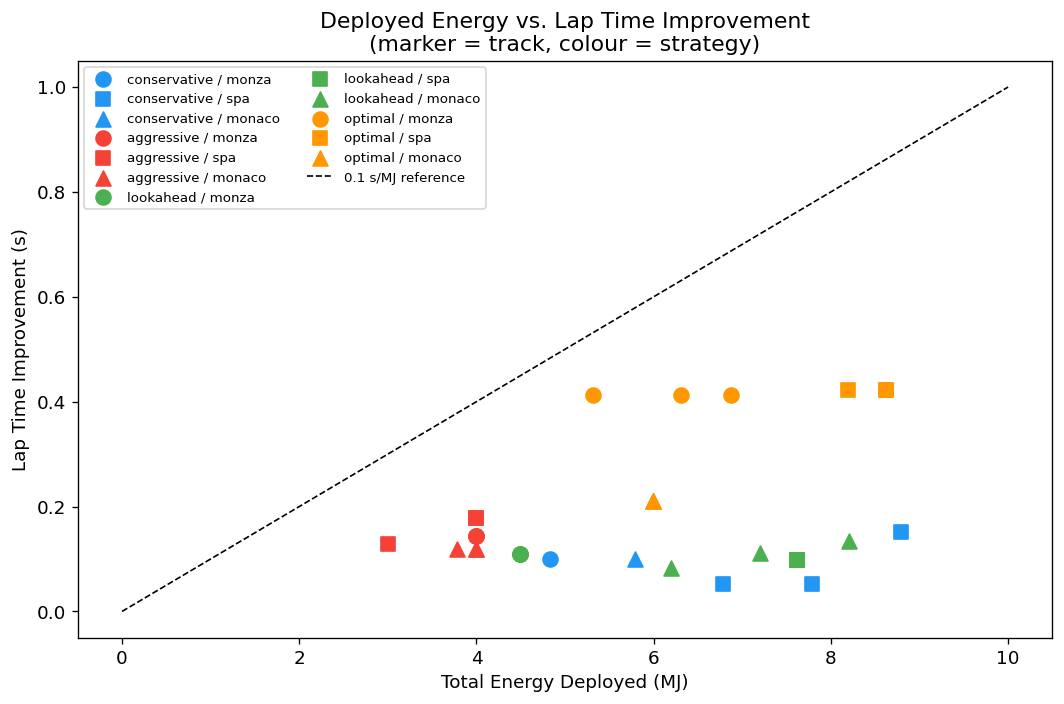

Slope ≈ 0.1 s/MJ, calibrated from real F1 ERS data (~0.4s for 4 MJ at Monza).


In [ ]:

# Only straight-deployed energy drives time savings — filter out conservative at low SOC
# (where it deploys entirely in corners and earns 0s) to avoid misleading the scatter.
# All other points are shown; marker shape = track, colour = strategy.
MARKERS = {"monza": "o", "spa": "s", "monaco": "^"}

fig, ax = plt.subplots(figsize=(9, 6))

for strat in STRATEGY_ORDER:
    for track in TRACKS:
        pts = df[(df.strategy == strat) & (df.track == track)]
        # drop conservative points where improvement is exactly 0 (corner-only deployment)
        pts = pts[pts.lap_time_improvement_s > 0]
        ax.scatter(
            pts.energy_deployed_j / 1e6,
            pts.lap_time_improvement_s,
            color=STRATEGY_COLORS[strat],
            marker=MARKERS[track],
            s=80,
            label=f"{strat} / {track}" if len(pts) else None,
        )

# Reference line: 0.1 s/MJ (the calibrated model coefficient)
x_ref = np.linspace(0, 10, 100)
ax.plot(x_ref, x_ref * 0.1, "k--", linewidth=1, label="0.1 s/MJ reference")

ax.set_xlabel("Total Energy Deployed (MJ)")
ax.set_ylabel("Lap Time Improvement (s)")
ax.set_title("Deployed Energy vs. Lap Time Improvement\n(marker = track, colour = strategy)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("results/fig_b_energy_vs_improvement.png", bbox_inches="tight")
plt.show()
print("Slope ≈ 0.1 s/MJ, calibrated from real F1 ERS data (~0.4s for 4 MJ at Monza).")


### Figure C — Sensitivity Tornado (Which Parameters Matter Most?)

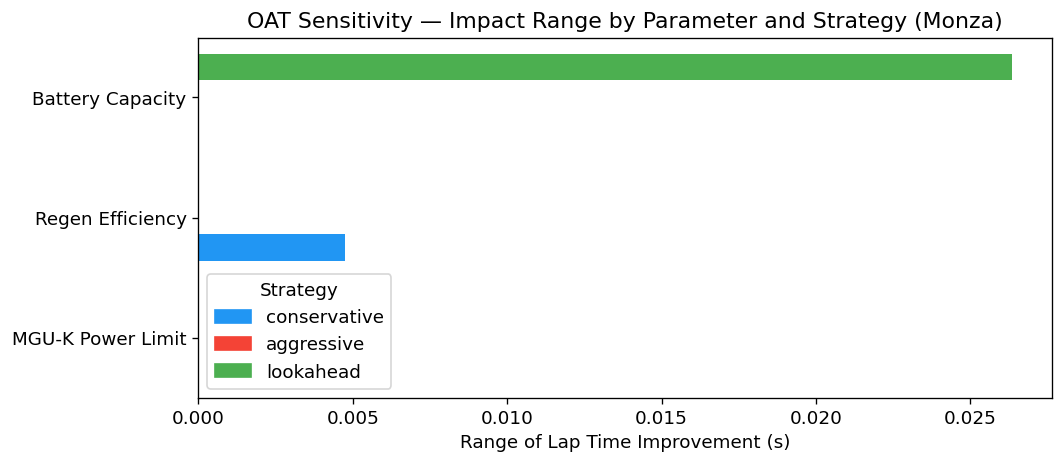

In [ ]:

# Run sensitivity analysis if not already done
import os
if not os.path.exists("results/sensitivity_oat.csv"):
    subprocess.run(["python", "-m", "experiments.sensitivity_analysis"], check=True)

oat = pd.read_csv("results/sensitivity_oat.csv")

# For each parameter + strategy, compute range of improvement_s across sweep values
rows = []
for param in oat["sweep_param"].unique():
    for strat in STRATEGY_ORDER[:3]:  # exclude optimal from OAT (not run in sensitivity script)
        sub = oat[(oat.sweep_param == param) & (oat.strategy == strat)]
        if len(sub) == 0:
            continue
        rng = sub["improvement_s"].max() - sub["improvement_s"].min()
        rows.append({"param": param, "strategy": strat, "range_s": rng})

tornado = pd.DataFrame(rows)
# Use mean range across strategies for ordering
order = tornado.groupby("param")["range_s"].mean().sort_values(ascending=True)

PARAM_LABELS = {
    "regen_efficiency":      "Regen Efficiency",
    "battery_capacity_mj":   "Battery Capacity",
    "mguk_power_kw":         "MGU-K Power Limit",
}

fig, ax = plt.subplots(figsize=(9, 4))
y_pos = np.arange(len(order))
for i, (param, _) in enumerate(order.items()):
    for j, strat in enumerate(STRATEGY_ORDER[:3]):
        row = tornado[(tornado.param == param) & (tornado.strategy == strat)]
        if len(row):
            ax.barh(i + j * 0.25 - 0.25, row["range_s"].values[0], 0.22,
                    color=STRATEGY_COLORS[strat], label=strat if i == 0 else "")

ax.set_yticks(y_pos)
ax.set_yticklabels([PARAM_LABELS.get(p, p) for p in order.index])
ax.set_xlabel("Range of Lap Time Improvement (s)")
ax.set_title("OAT Sensitivity — Impact Range by Parameter and Strategy (Monza)")
handles = [plt.Rectangle((0,0),1,1, color=STRATEGY_COLORS[s]) for s in STRATEGY_ORDER[:3]]
ax.legend(handles, STRATEGY_ORDER[:3], title="Strategy")
plt.tight_layout()
plt.savefig("results/fig_c_tornado.png", bbox_inches="tight")
plt.show()


### Figure D — Pareto Front: Lap Time Improvement vs. SOC Remaining

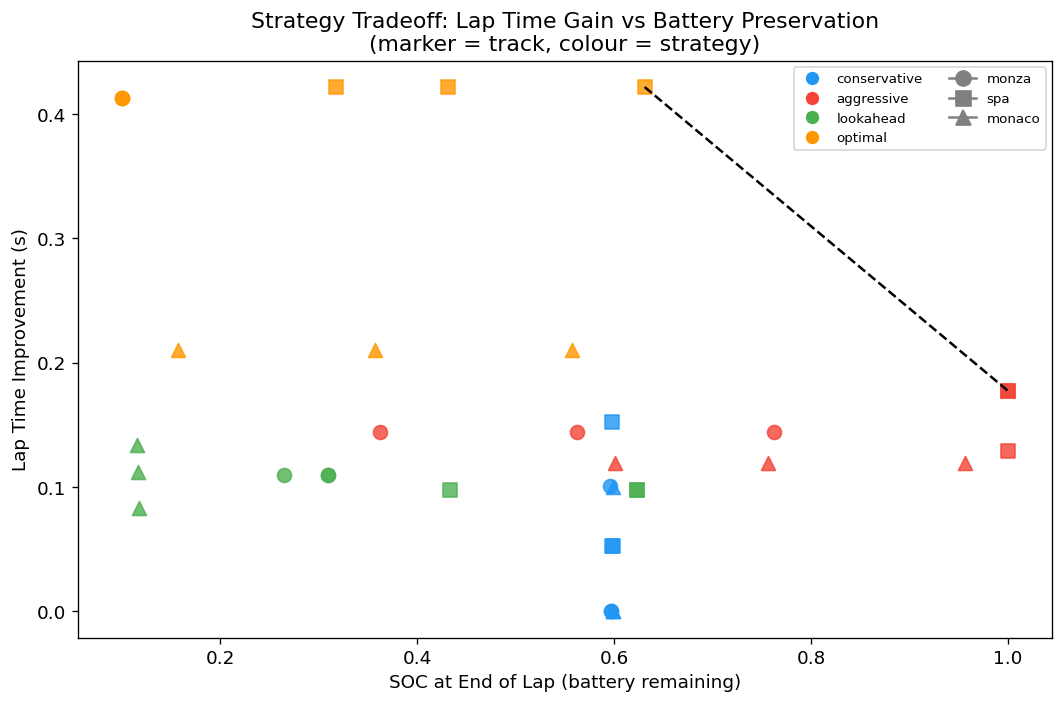

Pareto frontier = best achievable tradeoff between pace and battery conservation.


In [ ]:

# Pareto front: we want BOTH high improvement AND high SOC_end (battery preserved for next lap).
# Pareto-dominant = no other point has both better improvement AND better SOC_end.

def pareto_front(points):
    """Return boolean mask of Pareto-dominant points (maximise both x and y)."""
    dominated = np.zeros(len(points), dtype=bool)
    for i, p in enumerate(points):
        for j, q in enumerate(points):
            if i != j and q[0] >= p[0] and q[1] >= p[1] and (q[0] > p[0] or q[1] > p[1]):
                dominated[i] = True
                break
    return ~dominated

fig, ax = plt.subplots(figsize=(9, 6))

all_pts = []
for strat in STRATEGY_ORDER:
    for track in TRACKS:
        pts = df[(df.strategy == strat) & (df.track == track)]
        for _, row in pts.iterrows():
            ax.scatter(row["soc_end"], row["lap_time_improvement_s"],
                       color=STRATEGY_COLORS[strat],
                       marker=MARKERS[track], s=70, alpha=0.8)
            all_pts.append((row["soc_end"], row["lap_time_improvement_s"]))

# Draw Pareto frontier
pts_arr = np.array(all_pts)
mask = pareto_front(pts_arr)
front = pts_arr[mask]
front = front[front[:, 0].argsort()]
ax.plot(front[:, 0], front[:, 1], "k--", linewidth=1.5, label="Pareto frontier")

ax.set_xlabel("SOC at End of Lap (battery remaining)")
ax.set_ylabel("Lap Time Improvement (s)")
ax.set_title("Strategy Tradeoff: Lap Time Gain vs Battery Preservation\n(marker = track, colour = strategy)")

legend_strat = [plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=STRATEGY_COLORS[s],
                markersize=9, label=s) for s in STRATEGY_ORDER]
legend_track = [plt.Line2D([0],[0], marker=MARKERS[t], color="gray",
                markersize=9, label=t) for t in TRACKS]
ax.legend(handles=legend_strat + legend_track, fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("results/fig_d_pareto.png", bbox_inches="tight")
plt.show()
print("Pareto frontier = best achievable tradeoff between pace and battery conservation.")


### Figure E — Multi-Lap SOC Degradation (Stint Analysis)

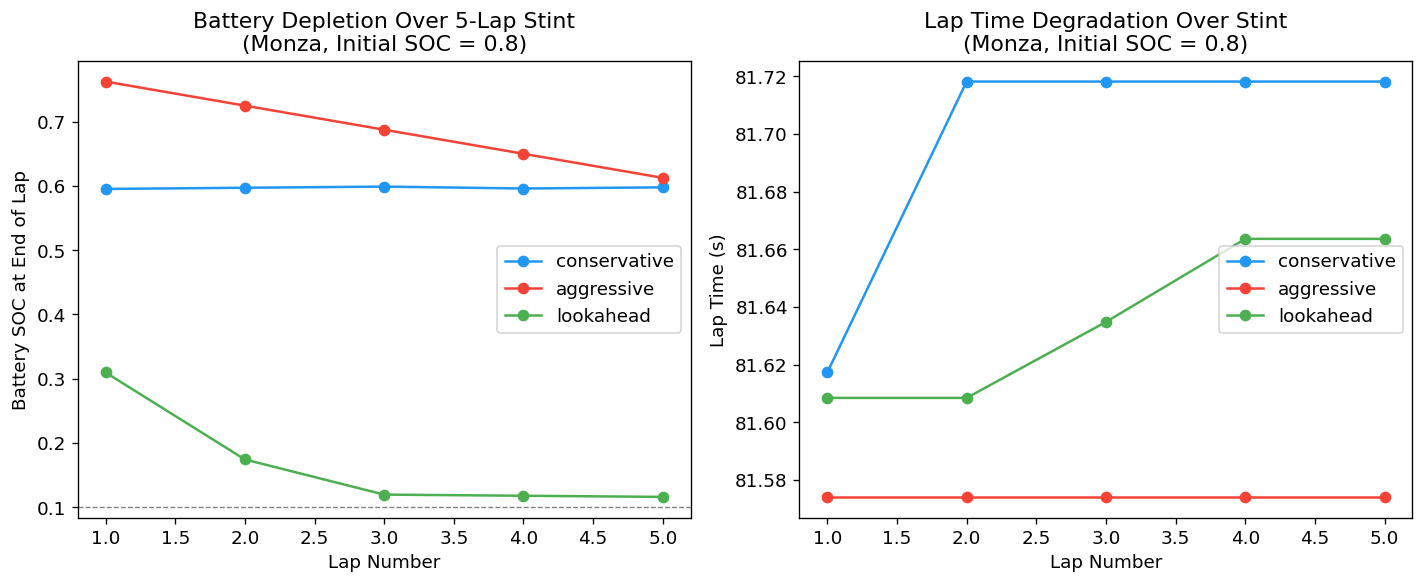

Lookahead drains battery by lap 3 → performance degrades; Aggressive depletes steadily but maintains pace.


In [ ]:

stint = pd.read_csv("results/stint_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for strat in ["conservative", "aggressive", "lookahead"]:
    s = stint[stint.strategy == strat]
    axes[0].plot(s["lap"], s["soc_end"], marker="o",
                 color=STRATEGY_COLORS[strat], label=strat)
    axes[1].plot(s["lap"], s["lap_time_s"], marker="o",
                 color=STRATEGY_COLORS[strat], label=strat)

axes[0].set_xlabel("Lap Number")
axes[0].set_ylabel("Battery SOC at End of Lap")
axes[0].set_title("Battery Depletion Over 5-Lap Stint\n(Monza, Initial SOC = 0.8)")
axes[0].legend()
axes[0].axhline(0.1, color="gray", linestyle="--", linewidth=0.8, label="SOC_MIN")

axes[1].set_xlabel("Lap Number")
axes[1].set_ylabel("Lap Time (s)")
axes[1].set_title("Lap Time Degradation Over Stint\n(Monza, Initial SOC = 0.8)")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/fig_e_stint.png", bbox_inches="tight")
plt.show()
print("Lookahead drains battery by lap 3 → performance degrades; Aggressive depletes steadily but maintains pace.")


---

## Key Findings Summary

| Finding | Value |
|---------|-------|
| Optimal vs Aggressive at Monza (same 4 MJ) | 0.40 s vs 0.14 s — **2.8× from timing** |
| Conservative paradox (SOC=0.6, Monza) | 3.83 MJ deployed, **0.0 s improvement** |
| Track architecture effect | Monaco 0.21 s (14% straights) vs Monza 0.40 s (53% straights) |
| Optimal SOC-invariance | 0.40 s at SOC=0.4, 0.6, 0.8 — optimizer compensates via regen |

See `docs/report.md` for the full research paper.

## Section 5 — Figure F: FIA Cap Sensitivity

**Research question:** How does relaxing the FIA deployment cap affect lap time benefit, and when does track architecture become the binding constraint instead of the regulation?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cap_df = pd.read_csv("../results/cap_sensitivity.csv")

fig, ax = plt.subplots(figsize=(8, 5))

colors = {"monza": "#E10600", "spa": "#1565C0", "monaco": "#FF8C00"}
labels = {"monza": "Monza (53% straights)", "spa": "Spa (43% straights)", "monaco": "Monaco (14% straights)"}
markers = {"monza": "o", "spa": "s", "monaco": "^"}

for track in ["monza", "spa", "monaco"]:
    subset = cap_df[cap_df["track"] == track].sort_values("cap_mj")
    ax.plot(subset["cap_mj"], subset["improvement_s"],
            color=colors[track], marker=markers[track], linewidth=2,
            markersize=8, label=labels[track])

ax.axvline(x=4, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Current FIA cap (4 MJ)")
ax.set_xlabel("FIA Deployment Cap (MJ)", fontsize=12)
ax.set_ylabel("Lap Time Improvement (s)", fontsize=12)
ax.set_title("Figure F: ERS Benefit vs. Regulatory Cap\n(OptimalController, SOC=0.6)", fontsize=13)
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.grid(True, alpha=0.3)
ax.set_xlim(1.5, 8.5)
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.savefig("../results/fig_f_cap_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/fig_f_cap_sensitivity.png")